<a href="https://colab.research.google.com/github/kmardamb/DATA-205-Spring-2026/blob/main/MardamBey_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1: nycflights13 Data Set

Karim MardamBey

4/3/2026

## 1. Introduction:

For Project 1 I will be using the nycflights13 dataset that I had used in Data 110 last semester from Rstudios, but I will be incorporating the techniques used in Data 201 and in the text book. The dataset is compiled of all the major New York City airports and their traffic from 2013. Variables in the dataset are things like; arrival and departure delays, specific airline carriers, destinations, distances, etc. The data is collected by the local airport and airline companies. The main limitations of the dataset is the location and time period, due to it being specific to NYC in 2013. The dataset doesn't directly imply how certain departure or arrival delays would occur. Ethical or bias concerns in the dataset derive from the lack of external information as to why specific airlines had particular delays.

Citation: Hadley Wickham. 2019. nycflights13: Flights that Departed NYC in 2013. R package version 1.0.1.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/byuidatascience/data4python4ds/master/data-raw/flights/flights.csv"
df = pd.read_csv(url)

df = df.drop(columns=["rownames"], errors = "ignore")

df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


## 2. Dataset Structure

In [ ]:
print ("Each row indicates a flight taken out of a New York City Airport in 2013")

In [10]:
df.shape

(336776, 19)

In [12]:
data_dict = {
    "Name": [
        "year", "month", "day", "dep_time", "sched_dep_time",
        "dep_delay", "arr_time", "sched_arr_time", "arr_delay",
        "carrier", "flight", "tailnum", "origin", "dest",
        "air_time", "distance", "hour", "minute", "time_hour"
    ],

    "Definition / Explanation": [
        "Year of the flight",
        "Month of the flight",
        "Day of the flight",
        "Actual departure time",
        "Scheduled departure time",
        "Departure delay in minutes",
        "Actual arrival time",
        "Scheduled arrival time",
        "Arrival delay in minutes",
        "Airline carrier code",
        "Flight number",
        "Aircraft identifier",
        "Departure airport",
        "Destination airport",
        "Time in air (minutes)",
        "Distance traveled (miles)",
        "Scheduled departure hour",
        "Scheduled departure minute",
        "Date and hour (timestamp)"
    ],

    "Type": [
        "int", "int", "int", "float", "int",
        "float", "float", "int", "float",
        "category", "int", "string", "category", "category",
        "float", "int", "int", "int", "datetime"
    ]
}

structure_df = pd.DataFrame(data_dict)

structure_df

,Name,Definition / Explanation,Type
0,year,Year of the flight,int
1,month,Month of the flight,int
2,day,Day of the flight,int
3,dep_time,Actual departure time,float
4,sched_dep_time,Scheduled departure time,int
5,dep_delay,Departure delay in minutes,float
6,arr_time,Actual arrival time,float
7,sched_arr_time,Scheduled arrival time,int
8,arr_delay,Arrival delay in minutes,float
9,carrier,Airline carrier code,category


## 4a. Quantitative Variable (Descriptive)

What were the amount of departure delays leaving from NYC in 2013? The dataset is descriptive because I am using quantitative measurements to analyze the delay in minutes per each airline.

I used .dropna() to remove any missing variables in the set. As for the statistical analysis, we can see that the chart is right-skewed due to the mean being higher than the median. The highest of the outliers can be seen at around 1000 minutes, while the average is around 200 minutes.


In [15]:
dep_delay_clean = df["dep_delay"].dropna()

In [16]:
dep_delay_clean.describe()

,dep_delay
count,328521.000000
mean,12.639070
std,40.210061
min,-43.000000
25%,-5.000000
50%,-2.000000
75%,11.000000
max,1301.000000


In [18]:
print("Mean:", dep_delay_clean.mean())
print("Median:", dep_delay_clean.median())
print("Standard Deviation:", dep_delay_clean.std())
print("Min:", dep_delay_clean.min())
print("Max:", dep_delay_clean.max())
print("Range:", dep_delay_clean.max() - dep_delay_clean.min())
print("IQR:", dep_delay_clean.quantile(0.75) - dep_delay_clean.quantile(0.25))

Mean: 12.639070257304708
Median: -2.0
Standard Deviation: 40.2100608921069
Min: -43.0
Max: 1301.0
Range: 1344.0
IQR: 16.0


In [20]:
Q1 = dep_delay_clean.quantile(0.25)
Q3 = dep_delay_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dep_delay_clean[(dep_delay_clean < lower_bound) | (dep_delay_clean > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Lower Bound: -29.0
Upper Bound: 35.0
Number of Outliers: 43216


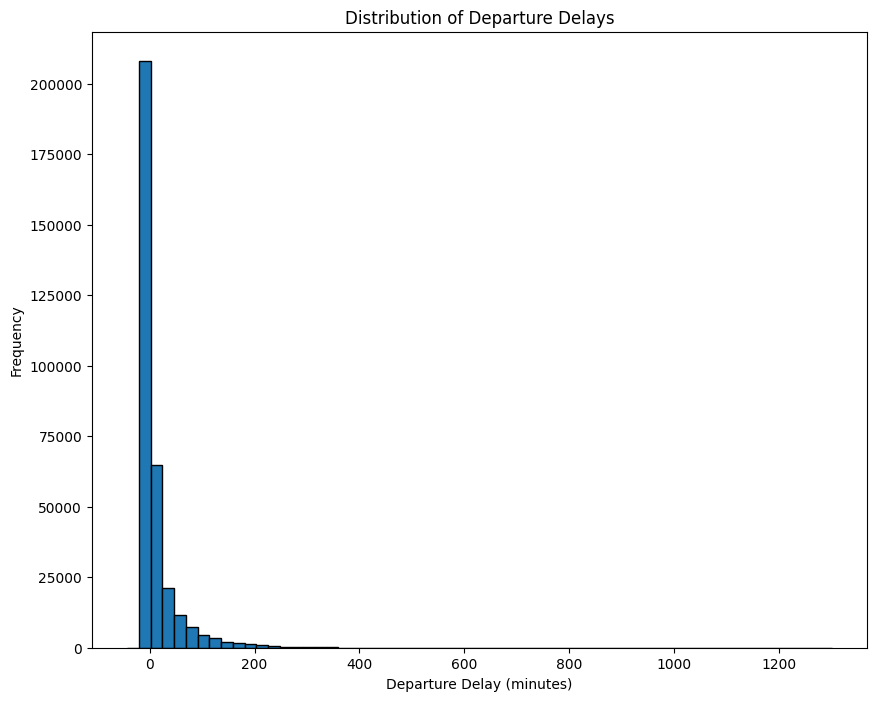

In [23]:
plt.figure(figsize=(10,8))
plt.hist(dep_delay_clean, bins= 60, edgecolor= "black")
plt.title("Distribution of Departure Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

## 4b. Categorical Variable (Descriptive)

My question for this analysis is what airlines has the most flights leaving New York City? I first cleaned NAs with .dropna(), and then got the flight count per airline. There are 16 total airlines so I did a bar chart to compare the amount of flights from those airlines. The bar chart below indicats that United Airlines had a total of 58665, being the most flown airline out of NYC in the data set.

In [28]:
carrier_clean = df["carrier"].dropna()
carrier_clean.head()

,carrier
0,UA
1,UA
2,AA
3,B6
4,DL


In [29]:
carrier_counts = carrier_clean.value_counts()
carrier_counts

,count
carrier,
UA,58665
B6,54635
EV,54173
DL,48110
AA,32729
MQ,26397
US,20536
9E,18460
WN,12275


In [30]:
carrier_summary = carrier_counts.reset_index()
carrier_summary.columns = ["carrier", "count"]
carrier_summary.head()

,carrier,count
0,UA,58665
1,B6,54635
2,EV,54173
3,DL,48110
4,AA,32729


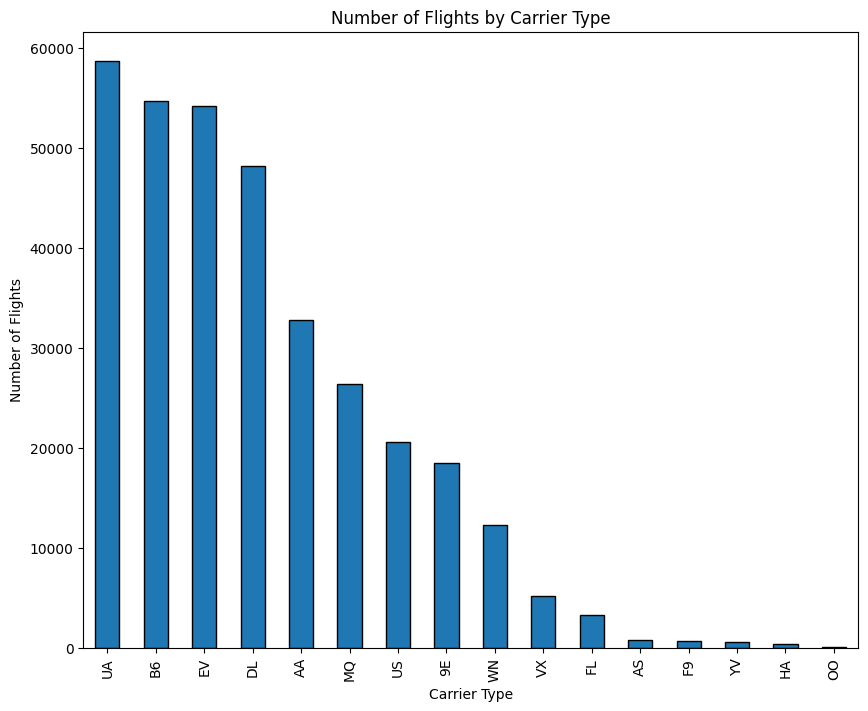

In [34]:
plt.figure(figsize=(10,8))
carrier_counts.plot(kind="bar", edgecolor="black")
plt.title("Number of Flights by Carrier Type")
plt.xlabel("Carrier Type")
plt.ylabel("Number of Flights")
plt.show()

## 4c. Relationship Between Variables (Exploratory)

The relationship between origin and departure delay, shows that EWR has the highest mean departure time at 15.11 minutes, while JFK and LGA are at 12.11 and 10.35 minutes of departure delay. Based on the statistical analysis below we can see a clear relationship between the specific airports locations and how they might factor into flight delay. As of today JFK is a busier airport then EWR, but in 2013 we can determine that EWR has higher departure delays.


In [55]:
airport_df = df[["origin", "dep_delay"]].dropna()
airport_df.head()

,origin,dep_delay
0,EWR,2.0
1,LGA,4.0
2,JFK,2.0
3,JFK,-1.0
4,LGA,-6.0


In [56]:
airport_summary = airport_df.groupby("origin")["dep_delay"].describe()
airport_summary

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
EWR,117596.0,15.107954,41.323704,-25.0,-4.0,-1.0,15.0,1126.0
JFK,109416.0,12.112159,39.035071,-43.0,-5.0,-1.0,10.0,1301.0
LGA,101509.0,10.346876,39.993021,-33.0,-6.0,-3.0,7.0,911.0


In [57]:
airport_mean = airport_df.groupby("origin")["dep_delay"].mean()
airport_mean

,dep_delay
origin,
EWR,15.107954
JFK,12.112159
LGA,10.346876


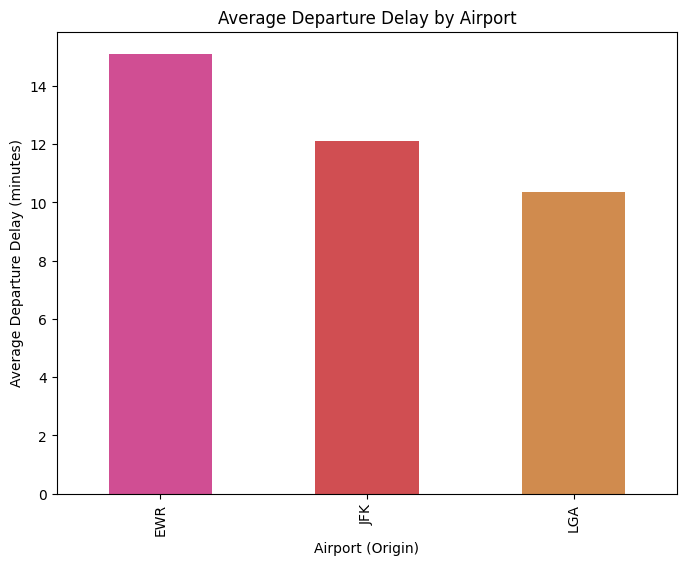

In [65]:
plt.figure(figsize=(8,6))

colors = ["#D04E93", "#D04E52", "#D08B4E"]  # Airports EWR, JFK, LGA

airport_mean.plot(kind="bar", color=colors)

plt.title("Average Departure Delay by Airport")
plt.xlabel("Airport (Origin)")
plt.ylabel("Average Departure Delay (minutes)")

plt.show()

## 4d. Nonparametric Inference (Median)

To estimate the average departure time delay, a random sample of approx. 10% was taken using .sample(frac = 0.10). The nonparametric inference sample shows a median departure delay of -2 minutes, indicating that typically flights leave relatively early from each airport.


In [69]:
sample_df = df[["dep_delay"]].dropna().sample(frac= 0.10, random_state= 201)
sample_df.head()

,dep_delay
10306,-1.0
155666,-2.0
130160,32.0
151475,-2.0
195084,-2.0


In [67]:
sample_median = sample_df["dep_delay"].median()
print("Sample median departure delay:", sample_median)

Sample median departure delay: -2.0


## 5. Conclusions and Recommendations

The Project 1 analysis of the New York City flights from 2013 indicates a variety of findings about the popularity of the airports and their delay timings. The distribution of flight delays showed on average that flights were either early or on time, with a small amount of outliers having massive delays.
Based on the data from 2013, the analysis showed that EWR airport had the highest average of departure delay in the New York area which indicates that location and seasonal timings affect the departure times.


Outside of the delay times and airport traffic, it would be nice to do some exploratory analysis on what conditions caused those delays, and also potentially look at a time series analysis showing the incease of traffic over X amount of years. The final conclusion that I took away from this project is that specific to the airport delays there were no specific correlations to be made as to why certain airlines and airports recived the most traffic and delays.
